# Horn of Africa Rainfall Seasonality

Seasonal cycle of hourly precipitation from ICON and IFS-FESOM
destinE climate projections for 2020 over the Horn of Africa.

**Requires**:
- Polytope auth (see `docs/polytope_setup.md`)
- Conda env `destine` (see `requirements.txt`)

In [43]:
import sys, os
_here = os.getcwd()
if "../get-data" not in sys.path:
    sys.path.insert(0, "../get-data")

import logging, warnings
import earthkit.data
import earthkit.plots
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from polytope_zarr import PolytopeZarrStore

# Silence verbose polytope / earthkit output
for _ln in ("polytope", "polytope.api", "earthkit.data", "urllib3"):
    logging.getLogger(_ln).setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=DeprecationWarning)

## 1. Fetch DestinE data

In [34]:
# ── Configuration ──────────────────────────────────────────────────
MODELS = ["ICON", "IFS-FESOM"]
BBOX = (5, 44, 10, 49)  # (south, west, north, east)

In [45]:
# ── Build lazy store (metadata only — no data fetched yet) ────────
hist_store = PolytopeZarrStore.from_climate_dt(
    models=MODELS,
    experiment="hist",
    levtype="sfc",
    years=range(2000, 2010),
    #frequency="hourly",
    #start_date="2000-01-01T00:00:00",
    #end_date="2010-12-31T23:00:00",
)

In [46]:
# ── Open as xarray Datasets (still lazy) ───────────────────────────
ds_hist = hist_store.open()

print("Historical store:", ds_hist)

Historical store: <xarray.Dataset> Size: 6GB
Dimensions:       (model: 2, time: 120, cell: 196608)
Coordinates:
  * model         (model) object 16B 'ICON' 'IFS-FESOM'
  * time          (time) datetime64[ns] 960B 2000-01-01 ... 2009-12-01
  * cell          (cell) int32 786kB 0 1 2 3 4 ... 196604 196605 196606 196607
Data variables: (12/34)
    avg_10u       (model, time, cell) float32 189MB ...
    avg_10v       (model, time, cell) float32 189MB ...
    avg_10ws      (model, time, cell) float32 189MB ...
    avg_2d        (model, time, cell) float32 189MB ...
    avg_2t        (model, time, cell) float32 189MB ...
    avg_ie        (model, time, cell) float32 189MB ...
    ...            ...
    avg_tnlwrf    (model, time, cell) float32 189MB ...
    avg_tnlwrfcs  (model, time, cell) float32 189MB ...
    avg_tnswrf    (model, time, cell) float32 189MB ...
    avg_tnswrfcs  (model, time, cell) float32 189MB ...
    avg_tprate    (model, time, cell) float32 189MB ...
    avg_tsrwe     (

In [47]:
# ── Fetch spatially‑subsetted climatologies with batching ──────────
# .polytope.sel() auto‑sets batch_years from the time slice, so each
# call = a single Polytope request per model × period

mean_data = {}  # model -> xr.DataArray

for model in MODELS:
    print(f"Fetching {model} ...")

    # Historical: 2001-01 to 2010-12
    hist_field = ds_hist["avg_tprate"].polytope.sel(
        model=model, time=slice("2000-01", "2009-12"), bbox=BBOX
        #model=model, time=slice("2001-01", "2002-12"), bbox=BBOX
    )
    mean_space = hist_field.mean(dim="points", skipna=True).groupby("time.month").mean() * 86400  # convert from kg m-2 s-1 to mm/day
    #mean_space = hist_field.mean(dim="points", skipna=True).resample(time="1D").groupby("time.day").mean() * 86400
    mean_data[model] = mean_space

Fetching ICON ...
  🌍 boundingbox request for avg_tprate (2000/2001/2002/2003/2004/2005/2006/2007/2008/2009-1/2/3/4/5/6/7/8/9/10/11/12)


ec8bad40-b580-4598-a9ee-8385f020d3e1.covjson:   0%|          | 0.00/841k [00:00<?, ?B/s]

Fetching IFS-FESOM ...
  🌍 boundingbox request for avg_tprate (2000/2001/2002/2003/2004/2005/2006/2007/2008/2009-1/2/3/4/5/6/7/8/9/10/11/12)


f6e936e3-21d9-4349-ae43-6ad73e7e04a4.covjson:   0%|          | 0.00/832k [00:00<?, ?B/s]

## 3. Load IMERG

In [54]:
imerg = xr.open_mfdataset(
    "../../acclimatise/get-data/imerg_africa/yearly_nc/pr_imerg_v07_africa_daily_200*.nc"
    ).sel(lat=slice(5, 10), lon=slice(44, 49)).mean(dim=["lat", "lon"], skipna=True).groupby("time.month").mean()
imerg

<xarray.Dataset> Size: 144B
Dimensions:  (month: 12)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    pr       (month) float32 48B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes: (12/14)
    BeginDate:       2000-01-01
    BeginTime:       00:00:00.000Z
    EndDate:         2000-01-01
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2000-01-01T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20000101-S000000-E002959.0000.V07B....
    ...              ...
    ProductionTime:  2024-11-14T14:54:09.574Z
    history:         Created 2026-07-15T13:34:07Z by download_imerg_v07_afric...
    region_lat_min:  -10.0
    region_lat_max:  25.0
    region_lon_min:  -20.0
    region_lon_max:  55.0

## 2. Plot seasonal cycle

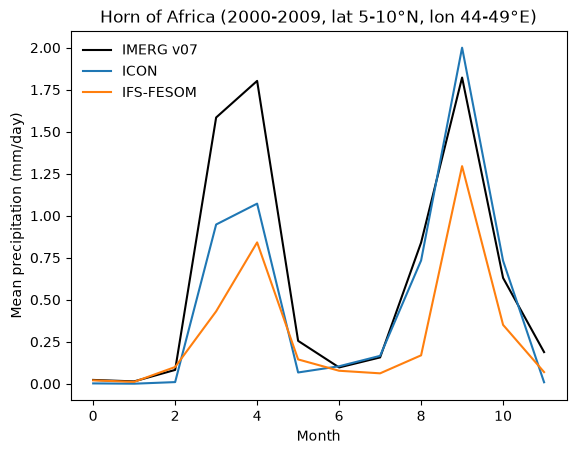

In [61]:
plt.plot(imerg.pr, label="IMERG v07", color="black")
plt.plot(mean_data["ICON"].avg_tprate, label="ICON")
plt.plot(mean_data["IFS-FESOM"].avg_tprate, label="IFS-FESOM")

plt.xlabel("Month")
plt.ylabel("Mean precipitation (mm/day)")
plt.title("Horn of Africa (2000-2009, lat 5-10°N, lon 44-49°E)")

plt.legend(edgecolor="white")
plt.savefig("plots/seasonality_hornofafrica.png")